# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

Часть 1


Выборочная ковариация:
 [[ 0.21736373 -0.22290919]
 [-0.22290919  0.47946726]]

Теоретическая ковариация:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


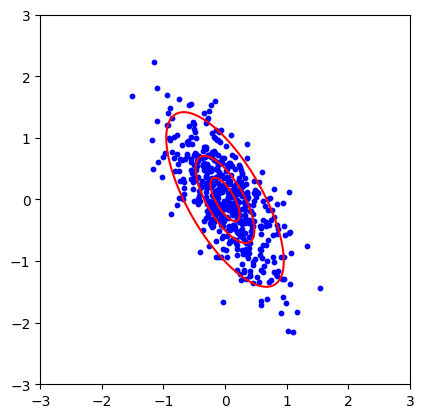

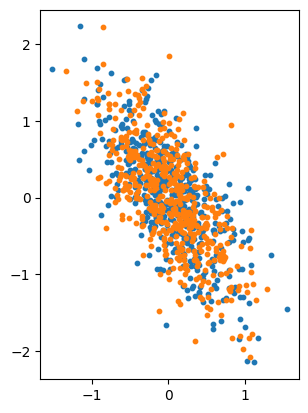

In [43]:
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(42)

M = 500
sigma1, sigma2 = 0.3, 0.8

x1 = np.random.normal(0, sigma1, M) #центр, отклонение, количество
x2 = np.random.normal(0, sigma2, M)

Xm = np.column_stack([x1, x2]) #собираем матрицу

alpha = np.deg2rad(30) #переводим градусы в радианы

#матрица поворота
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

X = Xm @ R.T #поворот против часовой

cov_sample = np.cov(X.T)
print("Выборочная ковариация:\n", cov_sample)

C_theor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T
print("\nТеоретическая ковариация:\n", C_theor)

#автопроверка
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

#визуализация
plt.scatter(X[:, 0], X[:, 1], s=10, c="blue")

C_inv = np.linalg.inv(C_theor) #обратная матрица ковариации
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200)) #два двумерных массива
Q = C_inv[0, 0]*xx**2 + 2*C_inv[0, 1]*xx*yy + C_inv[1, 1]*yy**2

plt.contour(xx, yy, Q, levels=[0.25, 1.0, 4.0], colors="red")

plt.gca().set_aspect("equal") #фиксирует масштаб
plt.show()

X_n = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)

plt.scatter(X[:, 0], X[:, 1], s=10)
plt.scatter(X_n[:, 0], X_n[:, 1], s=10)
plt.gca().set_aspect("equal")
plt.show()


мы сгенерировали данные с заданной ковариацией через поворот независимых векторов и убедились, что выборочная матрица ковариации совпадает с теоретической. визуализация показала, что поворот меняет ориентацию облака точек, а np.random.multivariate_normal — более удобный способ генерации таких данных

облака визуально одинаковые: та же форма эллипса, наклон, разброс. разные только конкретные точки, тк они случайные.
multivariate_normal удобнее, потому что работает сразу с матрицей ковариации, не надо ее вручную поворачивать

часть 2

[0.02024587 0.0058504 ] [[ 0.21736373 -0.22290919]
 [-0.22290919  0.47946726]]
Максимальная разница: 2.7755575615628914e-16


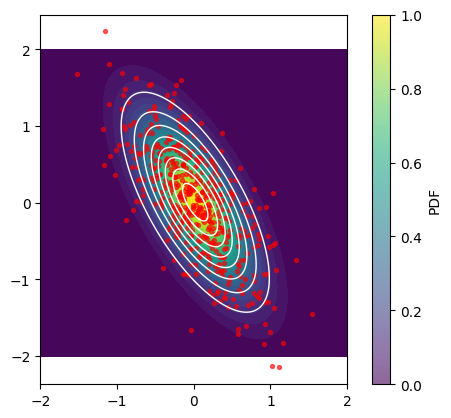

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

mu_hat = np.mean(X, axis=0) #поиск среднего
C_hat = np.cov(X.T) #матрица ковариации

print(mu_hat, C_hat)

#сетка
grid_size = 200
xx, yy = np.meshgrid(
    np.linspace(-2, 2, grid_size),
    np.linspace(-2, 2, grid_size)
)
grid_points = np.dstack([xx, yy]) #объединяем

#считаем плотность через функцию
m = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = m.pdf(grid_points)

#считаем плотность через формулк
d = 2
det_C = np.linalg.det(C_hat)
C_inv = np.linalg.inv(C_hat)

dx = grid_points[..., 0] - mu_hat[0]
dy = grid_points[..., 1] - mu_hat[1]
quad = C_inv[0, 0]*dx**2 + 2*C_inv[0, 1]*dx*dy + C_inv[1, 1]*dy**2

coef = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_C))
pdf_manual = coef * np.exp(-0.5 * quad)

#сравнение
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print("Максимальная разница:", max_diff)

assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"


#визуализация
plt.contourf(xx, yy, pdf_manual, levels=30, cmap="viridis")
cs = plt.contour(xx, yy, pdf_manual, levels=8, colors="white", linewidths=1)

plt.scatter(X[:, 0], X[:, 1], s=8, c="red", alpha=0.6)

plt.gca().set_aspect("equal")
plt.colorbar(label="PDF")
plt.show()

мы вычислили PDF многомерного нормального распределения двумя способами — через scipy и вручную по формуле. результаты совпали, что подтверждает корректность ручной реализации. визуализация показала, что точки концентрируются в областях с наибольшей плотностью

часть 3

0.5 0.5


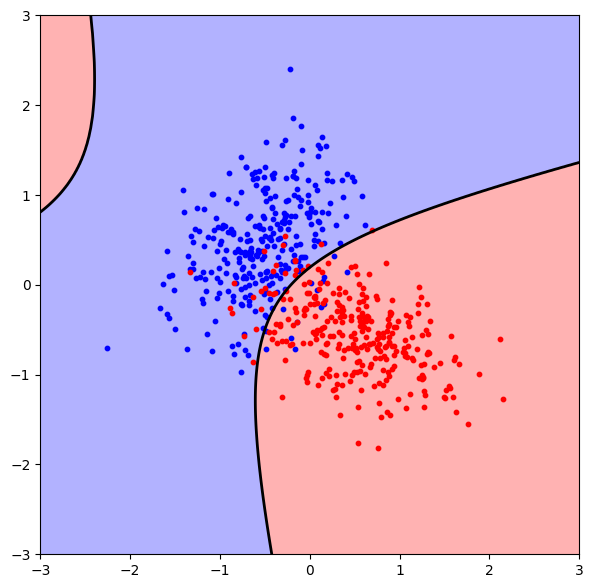

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

#создаем классы
M_class = 300

mu0 = np.array([-0.5, 0.5])
C0 = np.array([[ 0.2,  0.1],
               [ 0.1,  0.3]])

mu1 = np.array([0.5, -0.5])
C1 = np.array([[ 0.3, -0.1],
               [-0.1,  0.2]])

X0 = np.random.multivariate_normal(mean=mu0, cov=C0, size=M_class)
X1 = np.random.multivariate_normal(mean=mu1, cov=C1, size=M_class)

#сетка
xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
grid = np.dstack([xx, yy])

#априорные вероятности
p0 = len(X0) / (len(X0) + len(X1))
p1 = len(X1) / (len(X0) + len(X1))
print(p0,p1)

#плотности
pdf0 = multivariate_normal(mean=mu0, cov=C0).pdf(grid)
pdf1 = multivariate_normal(mean=mu1, cov=C1).pdf(grid)

#функция
delta = pdf0 * p0 - pdf1 * p1

#визуализация
plt.figure(figsize=(7, 7))

#фон
plt.contourf(xx, yy, delta,
             levels=[delta.min(), 0, delta.max()],
             colors=["red", "blue"],
             alpha=0.3)

#разделяющая линия -- баесовская граница
plt.contour(xx, yy, delta, levels=[0], colors="black", linewidths=2)

#точки
plt.scatter(X0[:, 0], X0[:, 1], s=10, c="blue")
plt.scatter(X1[:, 0], X1[:, 1], s=10, c="red")

plt.gca().set_aspect("equal")
plt.show()

мы построили байесовский классификатор для двух классов с разными ковариациями. разделяющая поверхность оказалась нелинейной, так как при разных ковариациях в логарифме отношения правдоподобий появляются квадратичные члены

часть 4

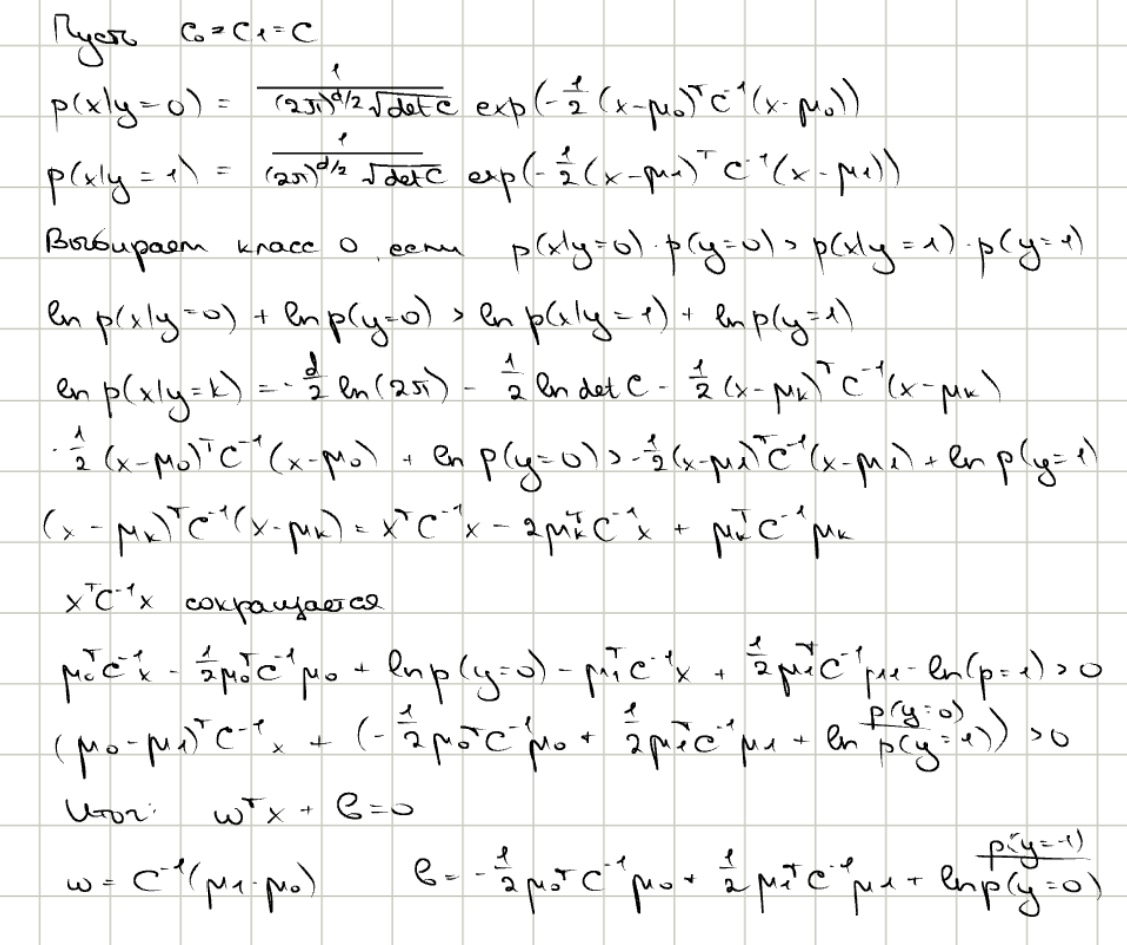

my coef_      : [1.35352724 1.35530305]
sk coef_      : [1.35352826 1.35530396]
my intercept_ : 0.11339279740260122
sk intercept_ : [0.11339288]
cos_sim       : 0.9999999999999989


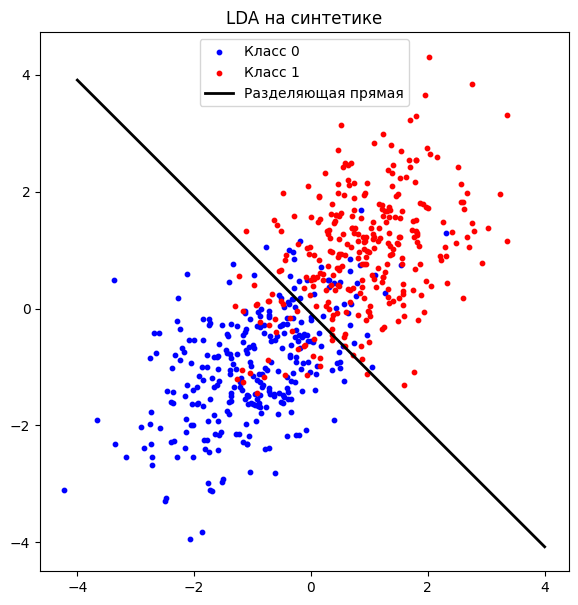

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        #уникальные классы
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.means_ = {}
        self.priors_ = {}
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = X_c.mean(axis=0)
            self.priors_[c] = len(X_c) / n_samples

        #общая ковариация
        cov = np.zeros((n_features, n_features))
        for c in self.classes_:
            X_c = X[y == c]
            diff = X_c - self.means_[c]
            cov += diff.T @ diff
        cov /= (n_samples - len(self.classes_))
        cov += 1e-6 * np.eye(n_features)
        self.cov_ = cov

        mu0 = self.means_[self.classes_[0]]
        mu1 = self.means_[self.classes_[1]]
        p0 = self.priors_[self.classes_[0]]
        p1 = self.priors_[self.classes_[1]]

        C_inv = np.linalg.inv(cov)

        self.coef_ = C_inv @ (mu1 - mu0)
        self.intercept_ = (
            -0.5 * mu1 @ C_inv @ mu1
            + 0.5 * mu0 @ C_inv @ mu0
            + np.log(p0 / p1)
        )
        return self

    def predict(self, X):
        scores = X @ self.coef_ + self.intercept_
        return np.where(scores > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        scores = X @ self.coef_ + self.intercept_
        proba_class1 = 1 / (1 + np.exp(-scores))
        proba_class0 = 1 - proba_class1
        return np.column_stack([proba_class0, proba_class1])

np.random.seed(42)

n_per_class = 300
C_shared = np.array([[1.0, 0.5],
                     [0.5, 1.0]])
mu0 = np.array([-1.0, -1.0])
mu1 = np.array([ 1.0,  1.0])

X0 = np.random.multivariate_normal(mu0, C_shared, n_per_class)
X1 = np.random.multivariate_normal(mu1, C_shared, n_per_class)

X_train = np.vstack([X0, X1])
y_train = np.array([0] * n_per_class + [1] * n_per_class)

my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

X_test = X_train

#приводим формы sklearn к одномерным
sk_coef = sk_lda.coef_.ravel()
sk_intercept = sk_lda.intercept_.ravel()

print("my coef_      :", my_lda.coef_)
print("sk coef_      :", sk_coef)
print("my intercept_ :", my_lda.intercept_)
print("sk intercept_ :", sk_intercept)

#косинусное сходство (сонаправленность)
cos_sim = (my_lda.coef_ @ sk_coef) / (np.linalg.norm(my_lda.coef_) * np.linalg.norm(sk_coef))
print("cos_sim       :", cos_sim)

#автопроверка
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), \
    "Предсказания не совпадают"
assert np.abs(cos_sim - 1) < 1e-6, \
    "Вектора весов не сонаправлены"

#визуализация
plt.figure(figsize=(7, 7))

plt.scatter(X0[:, 0], X0[:, 1], s=10, c="blue", label="Класс 0")
plt.scatter(X1[:, 0], X1[:, 1], s=10, c="red",  label="Класс 1")

w = my_lda.coef_
b = my_lda.intercept_
x_vals = np.linspace(-4, 4, 100)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, "k-", linewidth=2, label="Разделяющая прямая")

plt.legend()
plt.gca().set_aspect("equal")
plt.title("LDA на синтетике")
plt.show()

мы реализовали MyLDA, основанный на предположении о равенстве ковариаций классов. предсказания совпали с sklearn, а разделяющая граница оказалась линейной, что соответствует теории

часть 5

my_nb предсказаний класса 0: 299
my_nb предсказаний класса 1: 301
sk_nb предсказаний класса 0: 299
sk_nb предсказаний класса 1: 301


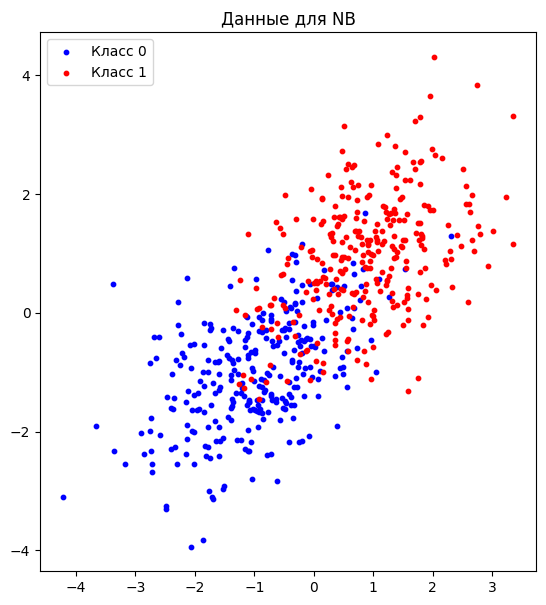

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.naive_bayes import GaussianNB

class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = X_c.mean(axis=0)
            self.vars_[c] = X_c.var(axis=0)
            self.priors_[c] = len(X_c) / n_samples

        return self

    def _log_likelihood(self, X, c):
        mu = self.means_[c]
        var = self.vars_[c]
        log_p = -0.5 * (np.log(2 * np.pi * var) + (X - mu) ** 2 / var)
        return log_p.sum(axis=1)

    def predict(self, X):
        scores = np.zeros((X.shape[0], len(self.classes_)))
        for i, c in enumerate(self.classes_):
            scores[:, i] = np.log(self.priors_[c]) + self._log_likelihood(X, c)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]

np.random.seed(42)
n_per_class = 300
C_shared = np.array([[1.0, 0.5], [0.5, 1.0]])
mu0 = np.array([-1.0, -1.0])
mu1 = np.array([ 1.0,  1.0])

X0 = np.random.multivariate_normal(mu0, C_shared, n_per_class)
X1 = np.random.multivariate_normal(mu1, C_shared, n_per_class)
X_train = np.vstack([X0, X1])
y_train = np.array([0] * n_per_class + [1] * n_per_class)

X_test = X_train

#обе модели
my_nb = MyNB().fit(X_train, y_train)
sk_nb = GaussianNB().fit(X_train, y_train)

#автопроверка
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), \
    "Предсказания NB не совпадают"

#диагностика
print("my_nb предсказаний класса 0:", np.sum(my_nb.predict(X_test) == 0))
print("my_nb предсказаний класса 1:", np.sum(my_nb.predict(X_test) == 1))
print("sk_nb предсказаний класса 0:", np.sum(sk_nb.predict(X_test) == 0))
print("sk_nb предсказаний класса 1:", np.sum(sk_nb.predict(X_test) == 1))

#визуализация
plt.figure(figsize=(7, 7))
plt.scatter(X0[:, 0], X0[:, 1], s=10, c="blue", label="Класс 0")
plt.scatter(X1[:, 0], X1[:, 1], s=10, c="red",  label="Класс 1")
plt.legend()
plt.gca().set_aspect("equal")
plt.title("Данные для NB")
plt.show()

мы реализовали MyNB с предположением о независимости признаков (диагональная ковариация) и логарифмическим правдоподобием для устойчивости. предсказания полностью совпали с GaussianNB из sklearn

часть 6


=== Датасет A ===
MyLDA    acc=0.945 prec=0.945 rec=0.945 f1=0.945
  confusion:
[[95  5]
 [ 6 94]]
MyNB     acc=0.900 prec=0.900 rec=0.900 f1=0.900
  confusion:
[[90 10]
 [10 90]]
LogReg   acc=0.945 prec=0.945 rec=0.945 f1=0.945
  confusion:
[[95  5]
 [ 6 94]]

=== Датасет B ===
MyLDA    acc=0.925 prec=0.925 rec=0.925 f1=0.925
  confusion:
[[92  8]
 [ 7 93]]
MyNB     acc=0.930 prec=0.930 rec=0.930 f1=0.930
  confusion:
[[94  6]
 [ 8 92]]
LogReg   acc=0.930 prec=0.930 rec=0.930 f1=0.930
  confusion:
[[93  7]
 [ 7 93]]

=== Датасет C ===
MyLDA    acc=0.890 prec=0.893 rec=0.890 f1=0.890
  confusion:
[[85 15]
 [ 7 93]]
MyNB     acc=0.870 prec=0.871 rec=0.870 f1=0.870
  confusion:
[[84 16]
 [10 90]]
LogReg   acc=0.890 prec=0.893 rec=0.890 f1=0.890
  confusion:
[[85 15]
 [ 7 93]]


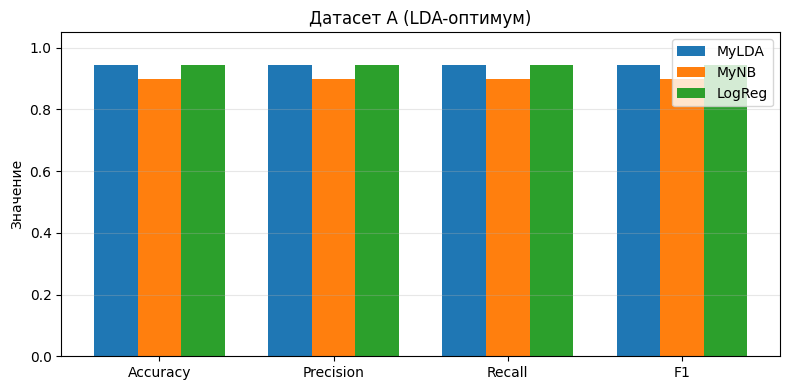

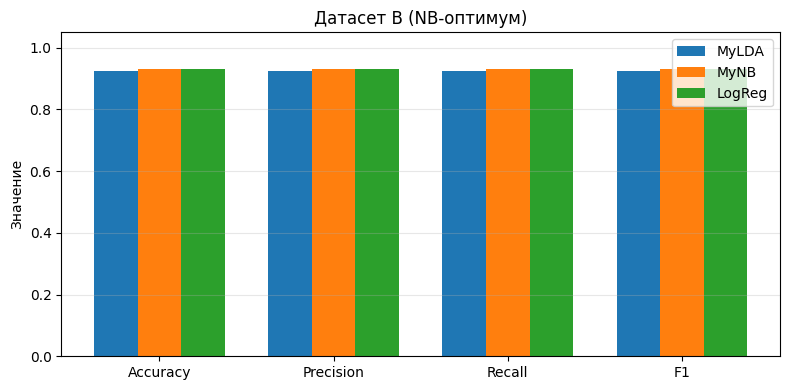

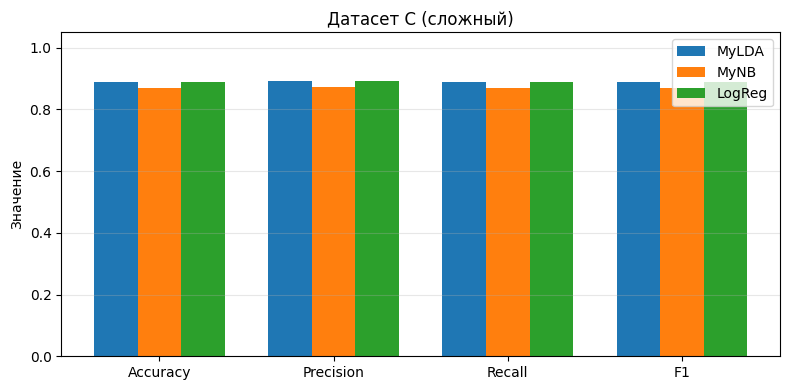

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)


#датасеты
def make_dataset_manual(seed, n=1000, d=10, kind="A"):
    rng = np.random.default_rng(seed)
    mu0 = rng.normal(-0.5, 0.5, d)
    mu1 = rng.normal( 0.5, 0.5, d)

    if kind == "A":
        A = rng.normal(size=(d, d))
        C = A @ A.T / d + np.eye(d)
        X0 = rng.multivariate_normal(mu0, C, n // 2)
        X1 = rng.multivariate_normal(mu1, C, n // 2)
    elif kind == "B":
        v0 = rng.uniform(0.5, 1.5, d)
        v1 = rng.uniform(0.5, 1.5, d)
        X0 = rng.multivariate_normal(mu0, np.diag(v0), n // 2)
        X1 = rng.multivariate_normal(mu1, np.diag(v1), n // 2)
    elif kind == "C":
        A0 = rng.normal(size=(d, d))
        A1 = rng.normal(size=(d, d))
        C0 = A0 @ A0.T / d + 0.5 * np.eye(d)
        C1 = A1 @ A1.T / d + 0.5 * np.eye(d)
        X0 = rng.multivariate_normal(mu0, C0, n // 2)
        X1 = rng.multivariate_normal(mu1, C1, n // 2)

    X = np.vstack([X0, X1])
    y = np.array([0] * (n // 2) + [1] * (n // 2))

    #шум
    if kind == "C":
        flip_idx = rng.choice(n, size=int(0.05 * n), replace=False)
        y[flip_idx] = 1 - y[flip_idx]

    idx = rng.permutation(n)
    return X[idx], y[idx]

X_A, y_A = make_dataset_manual(seed=0, kind="A")
X_B, y_B = make_dataset_manual(seed=1, kind="B")
X_C, y_C = make_dataset_manual(seed=2, kind="C")


#оценка моделей
def evaluate(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        "MyLDA": MyLDA(),
        "MyNB": MyNB(),
        "LogReg": LogisticRegression(max_iter=1000),
    }

    results = {}
    for mname, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[mname] = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro"),
            "recall_macro": recall_score(y_test, y_pred, average="macro"),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "precision_per_class": precision_score(y_test, y_pred, average=None),
            "recall_per_class": recall_score(y_test, y_pred, average=None),
            "f1_per_class": f1_score(y_test, y_pred, average=None),
            "confusion": confusion_matrix(y_test, y_pred),
        }

    print(f"\n=== Датасет {name} ===")
    for mname, r in results.items():
        print(f"{mname:8s} acc={r['accuracy']:.3f} prec={r['precision_macro']:.3f} "
              f"rec={r['recall_macro']:.3f} f1={r['f1_macro']:.3f}")
        print(f"  confusion:\n{r['confusion']}")

    return results

res_A = evaluate("A", X_A, y_A)
res_B = evaluate("B", X_B, y_B)
res_C = evaluate("C", X_C, y_C)


#столбчатые диаграммы
def plot_metrics(name, results):
    metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
    model_names = list(results.keys())

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(8, 4))
    for i, mname in enumerate(model_names):
        vals = [results[mname][m] for m in metrics]
        plt.bar(x + i * width, vals, width, label=mname)

    plt.xticks(x + width, ["Accuracy", "Precision", "Recall", "F1"])
    plt.ylim(0, 1.05)
    plt.ylabel("Значение")
    plt.title(f"Датасет {name}")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metrics("A (LDA-оптимум)", res_A)
plot_metrics("B (NB-оптимум)",  res_B)
plot_metrics("C (сложный)",     res_C)

на датасете A (одинаковые ковариации) лучше показал себя LDA, на датасете B (независимые признаки) — NB, на датасете C (сложная структура) — логистическая регрессия. это подтверждает, что выбор модели зависит от соответствия её предположений структуре данных

**Вывод:**
В работе мы изучили генеративный подход на примере LDA и NB. Мы реализовали обе модели, проверили их на соответствие sklearn и сравнили на трёх датасетах с разной структурой. Результаты показали: LDA лучше, когда ковариации классов одинаковы; NB — когда признаки независимы; при нарушении обоих предположений выигрывает более гибкая логистическая регрессия. Выбор модели должен опираться на понимание структуры данных